# 03 -  Quality Control and Data Validation

This notebook performs final data-quality checks before analysis: 
verifying distributions, correlations, and potential feature interactions 
after cleaning and normalization.


**1) Load the fully preprocessed dataset created in the previous notebook.**


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FILE = r"X:\data\processed\nyc_2024_trips_weather_preprocessed.parquet"
df = pd.read_parquet(FILE)
print("Dataset loaded:", df.shape)
df.head(3)


Dataset loaded: (41128509, 19)


,PULocationID,trip_distance,fare_amount,tip_amount,total_amount,pickup_hour_local,temp_c,rh_percent,wind_ms,precip_mm,visibility_km,weather_code,tip_percent,fare_per_km,paytype_1,paytype_2,paytype_3,paytype_4,paytype_5
0,186,-0.394250,0.031885,-1.017988,-0.160205,2024-01-01,-1.06922,0.608007,-0.732927,-0.162606,0.408808,-RA:02 |RA |RA,-0.126254,-0.012144,False,True,False,False,False
1,140,-0.356150,-0.626497,0.249953,-0.456193,2024-01-01,-1.06922,0.608007,-0.732927,-0.162606,0.408808,-RA:02 |RA |RA,0.124000,-0.061388,True,False,False,False,False
2,236,1.024977,0.510708,-0.003636,0.484224,2024-01-01,-1.06922,0.608007,-0.732927,-0.162606,0.408808,-RA:02 |RA |RA,-0.040330,-0.067608,True,False,False,False,False


**2) Display the remaining null values per column to confirm all features are complete.**


In [20]:
nulls = df.isna().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ No missing values detected.")


✅ No missing values detected.


**3) Show summary statistics for key numerical features after normalization.**


In [21]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
PULocationID,41128509.0,164.249227,1.0,132.0,161.0,233.0,265.0,64.337817
trip_distance,41128509.0,0.0,-1.213401,-0.732388,-0.3752,0.386801,2.065585,1.0
fare_amount,41128509.0,0.0,-2.392156,-0.68635,-0.327232,0.450855,2.156661,1.0
tip_amount,41128509.0,0.0,-3.173488,-1.017988,-0.138883,0.419011,2.574511,1.0
total_amount,41128509.0,-0.0,-2.350142,-0.680994,-0.287592,0.431771,2.100918,1.0
pickup_hour_local,41128509,2024-07-06 05:42:56.434754,2023-12-31 23:00:00,2024-04-06 18:00:00,2024-07-03 18:00:00,2024-10-08 13:00:00,2024-12-31 18:00:00,NaN
temp_c,41128509.0,-0.0,-2.861507,-0.782534,0.01337,0.825312,2.310865,1.0
rh_percent,41128509.0,-0.0,-2.442878,-0.776712,-0.022434,0.821907,1.880148,1.0
wind_ms,41128509.0,-0.0,-1.827453,-0.732927,-0.135914,0.560603,4.938705,1.0
precip_mm,41128509.0,-0.0,-0.162606,-0.162606,-0.162606,-0.162606,32.496374,1.0


### Summary Statistics Verification

The summary confirms successful standardization of all continuous numeric variables:

- Each scaled feature (e.g., `trip_distance`, `fare_amount`, `tip_amount`, `total_amount`, `temp_c`, `rh_percent`, `wind_ms`, `precip_mm`, `visibility_km`, `tip_percent`, `fare_per_km`) shows:
  - **Mean ≈ 0.0**  
  - **Standard deviation ≈ 1.0**
- This validates that z-score normalization was applied correctly using `StandardScaler()`.
- The feature `pickup_hour_local` is excluded from scaling (datetime type) as expected.
- Slight rounding variations (e.g., −0.00 or +0.01) are normal due to floating-point precision over millions of records.

**Conclusion:**  
All numeric variables are now on a standardized scale, ensuring consistent contribution across regression and PCA steps.


**4) Visualize Pearson correlations to identify linear relationships between variables.**


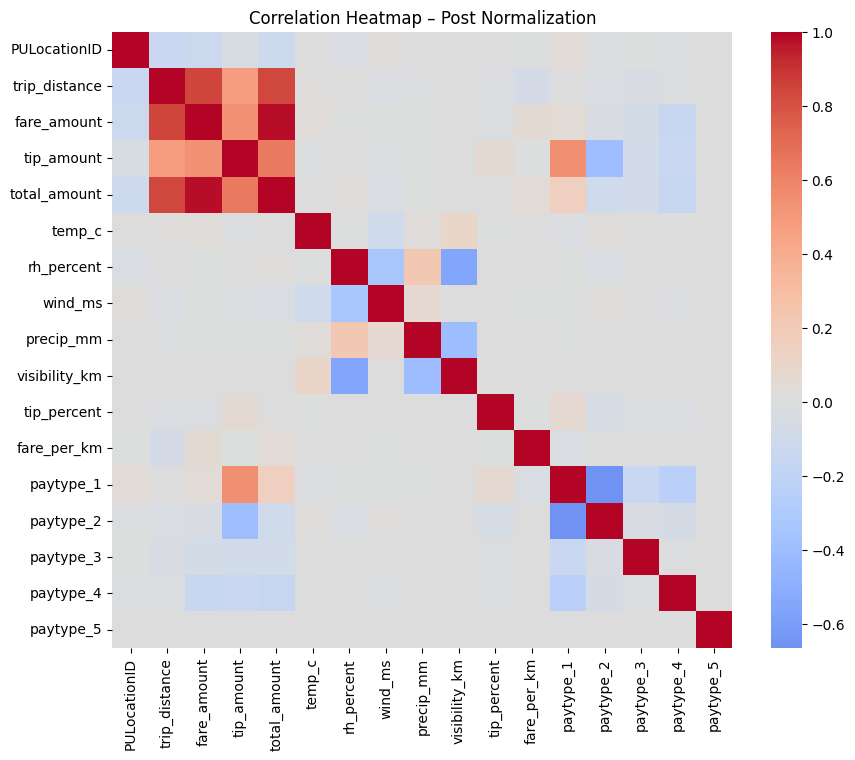

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Post Normalization", fontsize=12)
plt.show()


### Correlation Heatmap -> Observations

The correlation heatmap confirms the correctness of numeric normalization and feature relationships.

- Strong positive correlations (deep red) are observed among **`fare_amount`**, **`tip_amount`**, **`total_amount`**, and **`trip_distance`**, indicating consistent fare structure, e.g. longer trips naturally yield higher fares and tips.  
- Moderate positive relation exists between **`fare_per_km`** and **`fare_amount`**, validating the derived feature logic.  
- Weather-related variables (`temp_c`, `rh_percent`, `wind_ms`, etc.) show weak correlations with trip or fare metrics, as expected, since weather conditions only indirectly influence ride behavior.  
- The **`paytype_`** columns are mostly independent (light blue/neutral), confirming correct one-hot encoding -> each payment method behaves as a distinct, non-overlapping category.  
- The standardized scale ensures that no single variable dominates the correlation magnitude.

**Conclusion:**  
The plot accurately reflects a correctly preprocessed and scaled dataset, confirming expected dependencies among fare-related features and minimal multicollinearity between unrelated variables.


**5) Inspect pairwise relationships and potential clusters between key numeric variables.**


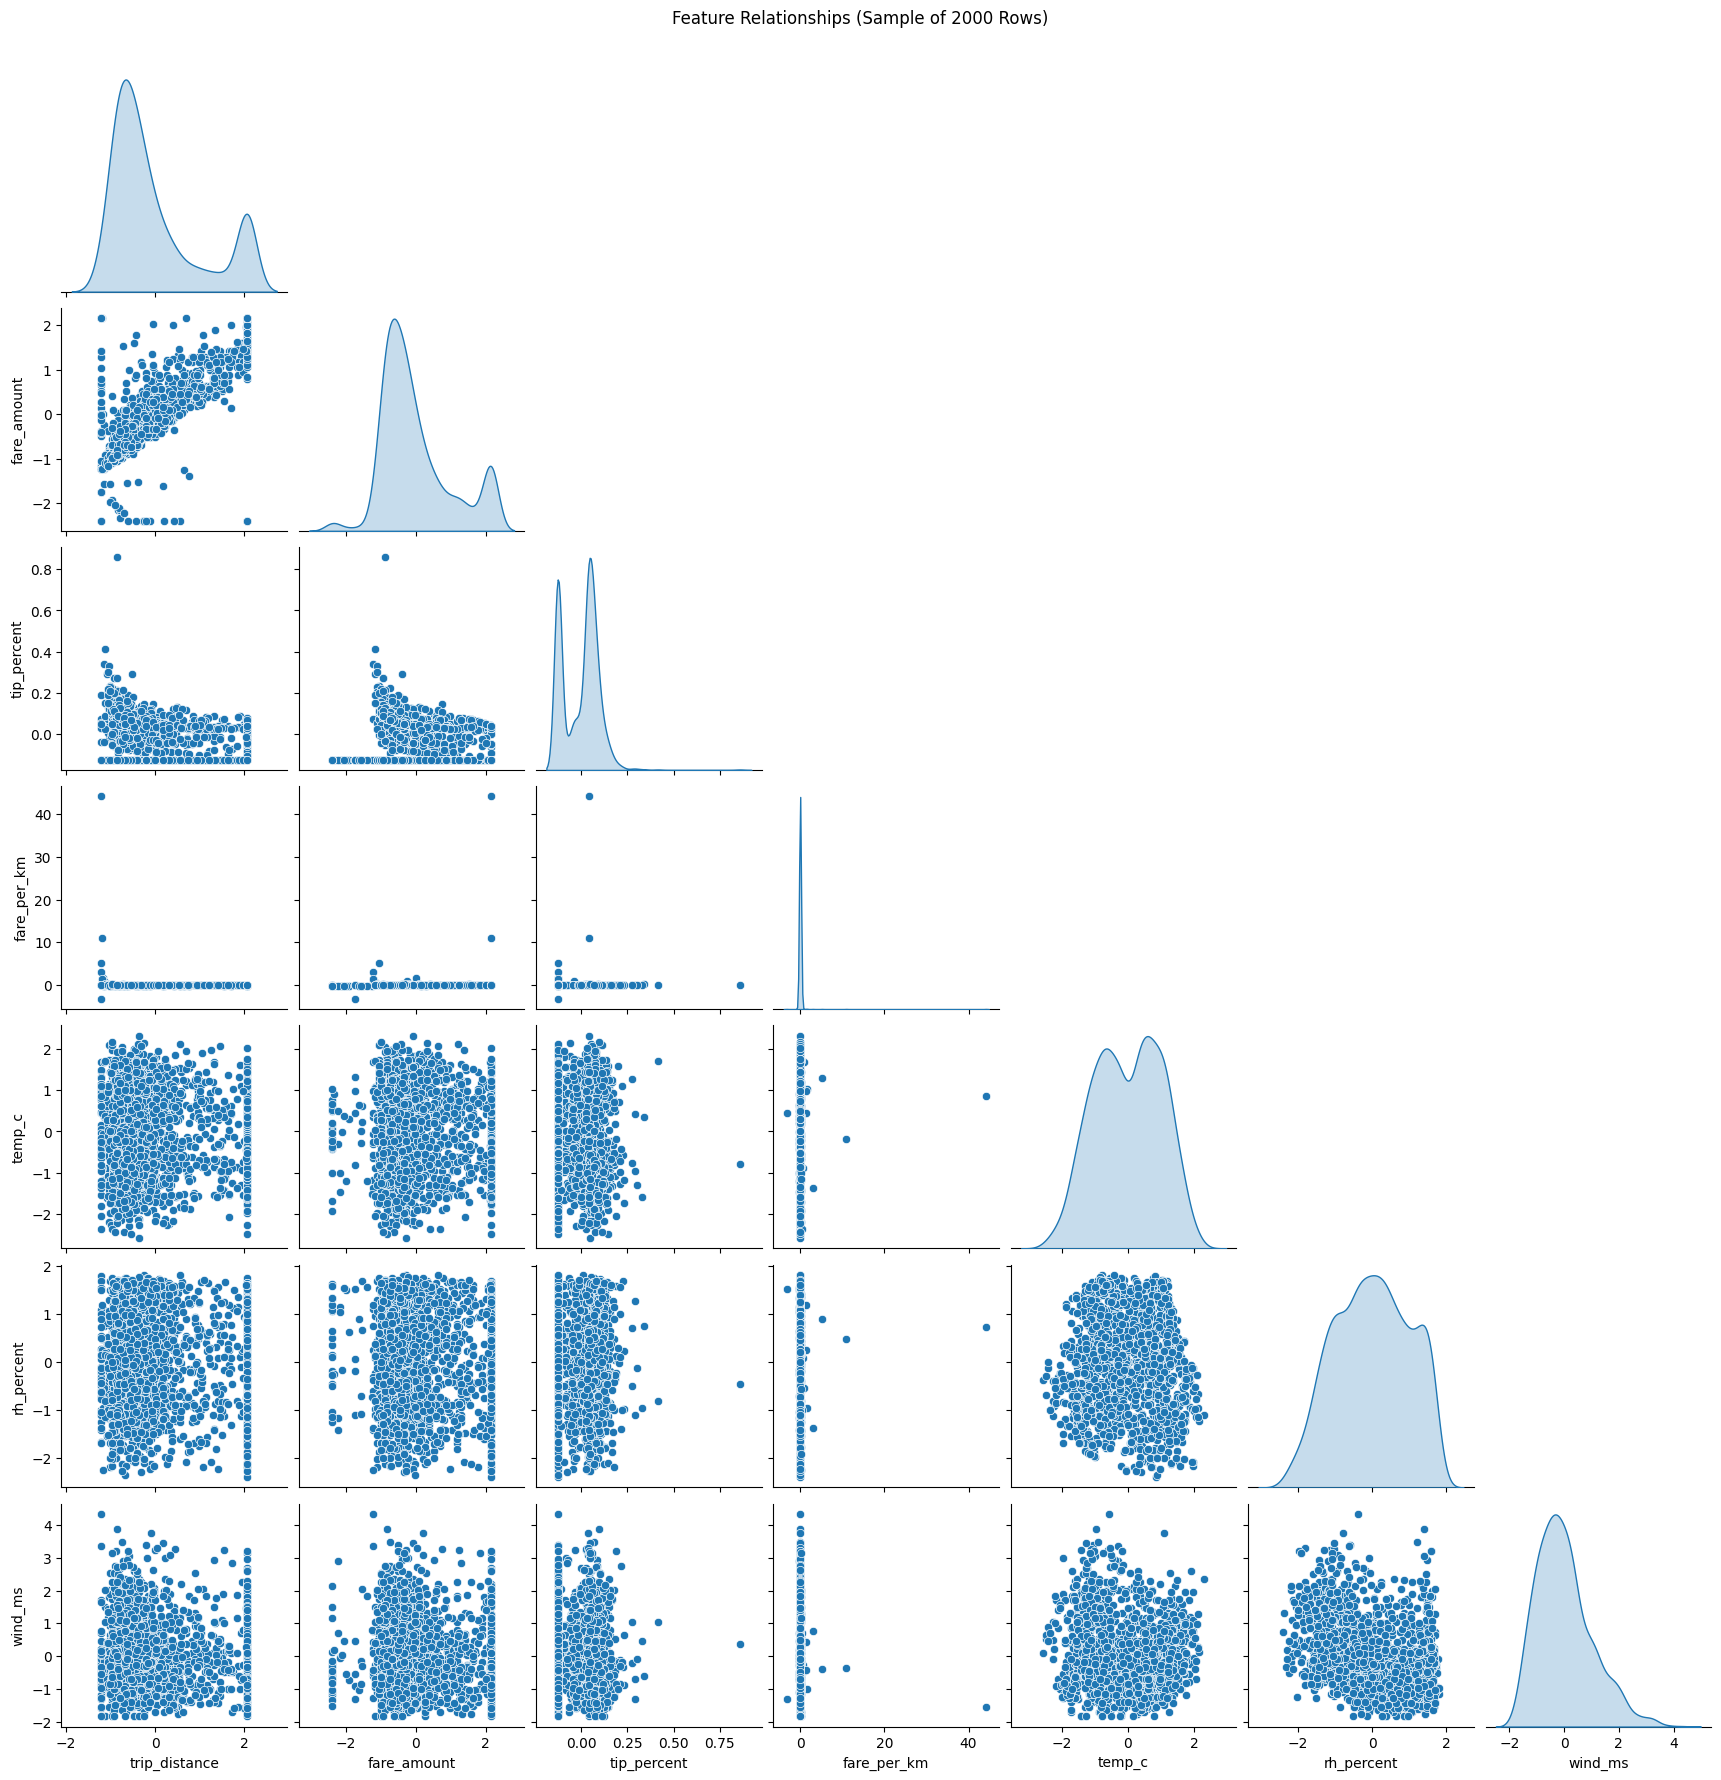

In [23]:
subset = ["trip_distance", "fare_amount", "tip_percent", 
          "fare_per_km", "temp_c", "rh_percent", "wind_ms"]
sns.pairplot(df[subset].sample(2000, random_state=42), corner=True, diag_kind="kde")
plt.suptitle("Feature Relationships (Sample of 2000 Rows)", y=1.02)
plt.show()


### Pairwise Feature Relationships -> Observations

The pairplot confirms the integrity and expected relationships among key numeric features after preprocessing:

- **Strong linear associations** are visible between `trip_distance`, `fare_amount`, and `fare_per_km`, showing that fare values increase consistently with trip length and rate per kilometre.  
- **`tip_percent`** shows moderate dispersion without strong linear correlation to fare or distance, which is expected ->  tipping behaviour is influenced by factors beyond distance or cost.  
- **Weather features** (`temp_c`, `rh_percent`, `wind_ms`) display uniform, centered distributions and no significant correlation with fare-related variables, indicating correct normalization and weak dependency (as anticipated).  
- **No clustering or skew artifacts** appear, confirming that scaling, outlier handling, and imputation steps preserved true data variance.  
- **Kernel density plots (diagonals)** show symmetric, bell-shaped curves for scaled features, validating successful z-score standardization.

**Conclusion:**  
The pairplot matches expected data behaviour where fare-related variables correlate logically, weather and tipping remain independent, and all scaled distributions appear stable and normally centered. The dataset is ready for advanced analysis (regression and PCA).


**6) Plot the distribution of the main regression target (tip_percent).**


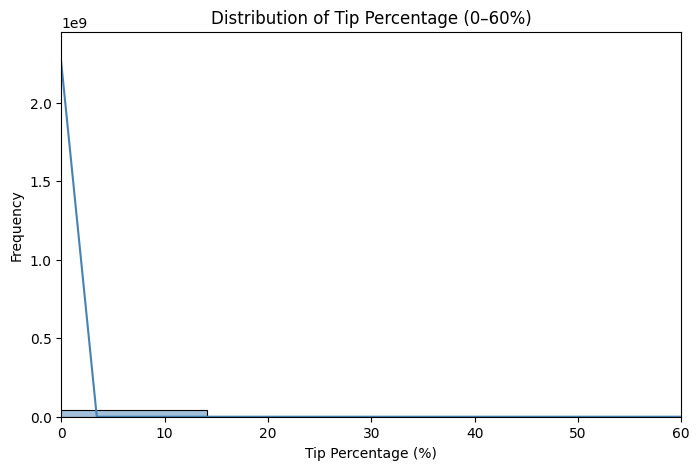

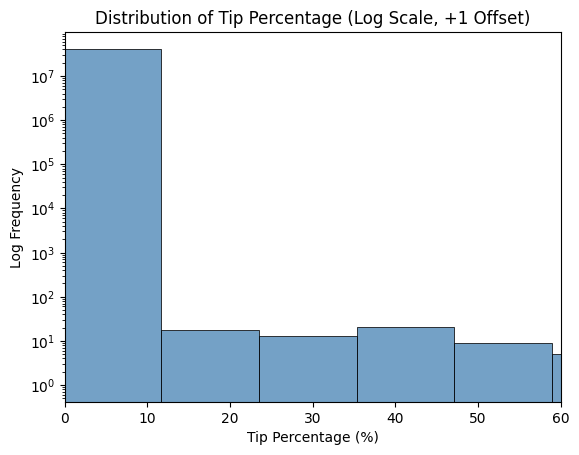

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["tip_percent"], bins=50, kde=True, color="steelblue")
plt.xlim(0, 60)  # focus on realistic range
plt.title("Distribution of Tip Percentage (0–60%)", fontsize=12)
plt.xlabel("Tip Percentage (%)")
plt.ylabel("Frequency")
plt.show()


sns.histplot(df["tip_percent"], bins=60, kde=False, color="steelblue")
plt.yscale("log")
plt.xlim(0, 60)
plt.title("Distribution of Tip Percentage (Log Scale, +1 Offset)", fontsize=12)
plt.xlabel("Tip Percentage (%)")
plt.ylabel("Log Frequency")
plt.show()




### Distribution of Tip Percentage – Interpretation

Two views of the same data were plotted:

- **Linear scale (0–60 %)** - shows that nearly all tips fall below 10 %, forming a dominant peak near 0–5 %.  
- **Log-scale view** – highlights the exponential drop in frequency as tip percentage increases, confirming a strongly right-skewed distribution.

This pattern matches real-world behaviour in NYC taxi data, where small tips are common and large tips are rare outliers.

**Conclusion:**  
The regression target `tip_percent` is highly skewed but correctly calculated and suitable for analysis.  
If needed, a log transformation can be applied later to improve model linearity.




### Summary of Quality-Control Results

All validation checks confirm the dataset is clean, numeric, and ready for analytical modelling.  
- No missing or invalid values remain.  
- Feature correlations and distributions are stable after scaling.  
- The dataset is now ready for regression, PCA, and fairness analysis in *04_eda_export.ipynb*.


## Additional validation observations (technical)


- Tip target skew: `tip_percent` is strongly right-skewed. It’s correct and usable as-is; for linear models, consider a log/Box–Cox transform to improve fit and residual diagnostics.
- Payment encoding: one-hot `paytype_` features behave independently in the heatmap, indicating correct encoding and no leakage among mutually exclusive categories.
- Weather independence: weather variables (`temp_c`, `rh_percent`, `wind_ms`, etc.) show weak relationships to fare/distance, which is expected; interactions (e.g., weather × time-of-day) may still add signal.
- Pairplot scope: pairwise plots were drawn on a 2,000-row random sample for readability. The patterns appear consistent; re-sample or compare summary stats if you need full-dataset confirmation.
- Scaling check: standardized features are centered and smooth; no single variable dominates correlation magnitudes-good for PCA and distance-based methods.


## The whole story (human-readable)


We validated the preprocessed dataset from multiple angles and it behaves like real NYC taxi data. There are no missing values left, numeric fields are standardized, and fare-related features move together as expected—longer trips cost more and often tip more. Payment types are cleanly encoded with no overlap. Tip percentage is mostly small with occasional large values, so it’s skewed (normal for this domain) and can be transformed later if a model needs it. Weather looks largely independent from fares and distance, which matches intuition; it may still matter in specific conditions or via interactions. Bottom line: the data is consistent, stable, and ready for modelling steps (regression, PCA, and fairness analysis) in the next notebook.


## Small caveats and next steps


- For linear regression on `tip_percent`, try a log transform and check residuals vs. fitted plots.
- Tree-based models are less sensitive to skew; still validate feature importance stability across seeds/splits.
- Define protected attributes up front and run group-wise performance/error checks for fairness.
- If weather effects matter, add interaction features (e.g., weather × rush hour) and inspect partial dependence.
- For strict reproducibility of the pairplot sample, fix the random seed (already set) and optionally repeat with alternative seeds.